In [1]:
import pandas as pd
import numpy as np
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
df= pd.read_csv("C:/Users/강태희/Documents/MLB_allgameinfo_innings.csv")

In [3]:
df.head()

,gid,visteam,hometeam,site,date,number,starttime,daynight,usedh,timeofgame,...,v_extra_runs_x,h_extra_runs_x,extra_run_diff_x,v_extra_runs_y,h_extra_runs_y,extra_run_diff_y,v_extra_runs,h_extra_runs,extra_run_diff,time_per_9_innings
0,ANA202104010,CHA,ANA,ANA01,2021-04-01,0,7:05PM,night,1,171,...,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,181.058824
1,CHN202104010,PIT,CHN,CHI11,2021-04-01,0,1:20PM,day,0,240,...,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,240.000000
2,CIN202104010,SLN,CIN,CIN09,2021-04-01,0,4:10PM,day,0,211,...,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,211.000000
3,COL202104010,LAN,COL,DEN02,2021-04-01,0,2:10PM,day,0,226,...,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,239.294118
4,DET202104010,CLE,DET,DET05,2021-04-01,0,1:10PM,day,1,183,...,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,193.764706


In [4]:
df.tail()

,gid,visteam,hometeam,site,date,number,starttime,daynight,usedh,timeofgame,...,v_extra_runs_x,h_extra_runs_x,extra_run_diff_x,v_extra_runs_y,h_extra_runs_y,extra_run_diff_y,v_extra_runs,h_extra_runs,extra_run_diff,time_per_9_innings
12024,SDN202509280,ARI,SDN,SAN02,2025-09-28,0,12:10PM,day,1,191,...,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,202.235294
12025,SEA202509280,LAN,SEA,SEA03,2025-09-28,0,12:10PM,day,1,163,...,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,163.000000
12026,SFN202509280,COL,SFN,SFO03,2025-09-28,0,12:05PM,day,1,138,...,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,146.117647
12027,TOR202509280,TBA,TOR,TOR02,2025-09-28,0,3:07PM,day,1,179,...,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,189.529412
12028,WAS202509280,CHA,WAS,WAS11,2025-09-28,0,3:05PM,day,1,143,...,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,143.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12029 entries, 0 to 12028
Data columns (total 50 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gid                 12029 non-null  object 
 1   visteam             12029 non-null  object 
 2   hometeam            12029 non-null  object 
 3   site                12029 non-null  object 
 4   date                12029 non-null  object 
 5   number              12029 non-null  int64  
 6   starttime           12029 non-null  object 
 7   daynight            12029 non-null  object 
 8   usedh               12029 non-null  int64  
 9   timeofgame          12029 non-null  int64  
 10  attendance          12029 non-null  float64
 11  sky                 12029 non-null  object 
 12  temp                12029 non-null  int64  
 13  winddir             12029 non-null  object 
 14  windspeed           12029 non-null  int64  
 15  wp                  12028 non-null  object 
 16  lp  

In [6]:
df.shape

(12029, 50)

In [7]:
df.isna().sum()

gid                       0
visteam                   0
hometeam                  0
site                      0
date                      0
number                    0
starttime                 0
daynight                  0
usedh                     0
timeofgame                0
attendance                0
sky                       0
temp                      0
winddir                   0
windspeed                 0
wp                        1
lp                        1
save                   6003
vruns                     0
hruns                     0
wteam                     1
lteam                     1
season                    0
Season                    0
season_spring             0
season_summer             0
season_autumn             0
day_of_week               0
day_name                  0
is_weekend                0
mia_win                   0
more_game                 0
is_night                  0
is_dome                   0
weather_severity          0
dir_weight          

In [8]:
# 결측치 있는 컬럼 출력
df.columns[df.isnull().any()]

Index(['wp', 'lp', 'save', 'wteam', 'lteam', 'total_innings', 'v_extra_runs_x',
       'h_extra_runs_x', 'extra_run_diff_x', 'v_extra_runs_y',
       'h_extra_runs_y', 'extra_run_diff_y', 'v_extra_runs', 'h_extra_runs',
       'extra_run_diff', 'time_per_9_innings'],
      dtype='object')

In [9]:
df[df['wteam'].isna()]

,gid,visteam,hometeam,site,date,number,starttime,daynight,usedh,timeofgame,...,v_extra_runs_x,h_extra_runs_x,extra_run_diff_x,v_extra_runs_y,h_extra_runs_y,extra_run_diff_y,v_extra_runs,h_extra_runs,extra_run_diff,time_per_9_innings
11045,NLS202507150,ALS,NLS,ATL03,2025-07-15,0,8:00PM,night,1,200,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


ALS와 NLS는 특정 구단(Marlins, Dodgers 등)을 의미X, 메이저리그 올스타전을 위해 구성된 연합 팀
- ALS (American League Stars): 아메리칸 리그 소속 구단들의 스타 선수들로 구성된 팀
- NLS (National League Stars): 내셔널 리그 소속 구단들의 스타 선수들로 구성된 팀

위의 경기는 2025년 7월 15일에 열린 올스타전 본 경기이기 때문에, 특정 연고지 팀이 아닌 리그 이름을 따서 기록된 것임

In [10]:
df = df.dropna(subset=['wteam'])

In [11]:
# ALS 또는 NLS가 포함된 경기들만 필터링하여 출력
all_star_games = df[(df['visteam'].isin(['ALS', 'NLS'])) | (df['hometeam'].isin(['ALS', 'NLS']))]
all_star_games

,gid,visteam,hometeam,site,date,number,starttime,daynight,usedh,timeofgame,...,v_extra_runs_x,h_extra_runs_x,extra_run_diff_x,v_extra_runs_y,h_extra_runs_y,extra_run_diff_y,v_extra_runs,h_extra_runs,extra_run_diff,time_per_9_innings
3692,NLS202207190,ALS,NLS,LOS03,2022-07-19,0,5:00PM,night,1,191,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6096,ALS202307110,NLS,ALS,SEA03,2023-07-11,0,5:00PM,night,1,183,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8619,ALS202407160,NLS,ALS,ARL03,2024-07-16,0,7:00PM,night,1,148,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
df[df['time_per_9_innings'].isna()]

,gid,visteam,hometeam,site,date,number,starttime,daynight,usedh,timeofgame,...,v_extra_runs_x,h_extra_runs_x,extra_run_diff_x,v_extra_runs_y,h_extra_runs_y,extra_run_diff_y,v_extra_runs,h_extra_runs,extra_run_diff,time_per_9_innings
3692,NLS202207190,ALS,NLS,LOS03,2022-07-19,0,5:00PM,night,1,191,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6096,ALS202307110,NLS,ALS,SEA03,2023-07-11,0,5:00PM,night,1,183,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8619,ALS202407160,NLS,ALS,ARL03,2024-07-16,0,7:00PM,night,1,148,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


올스타 게임은 정규 시즌 승률이나 순위에 반영되지 않는 '전시 경기(Exhibition Game)'임  
정규 시즌 데이터만 다루는 분석 목적에 따라 제거 

In [13]:
df = df.dropna(subset=['time_per_9_innings'])

In [14]:
df.isna().sum()

gid                       0
visteam                   0
hometeam                  0
site                      0
date                      0
number                    0
starttime                 0
daynight                  0
usedh                     0
timeofgame                0
attendance                0
sky                       0
temp                      0
winddir                   0
windspeed                 0
wp                        0
lp                        0
save                   6002
vruns                     0
hruns                     0
wteam                     0
lteam                     0
season                    0
Season                    0
season_spring             0
season_summer             0
season_autumn             0
day_of_week               0
day_name                  0
is_weekend                0
mia_win                   0
more_game                 0
is_night                  0
is_dome                   0
weather_severity          0
dir_weight          

In [15]:
df = df.reset_index(drop=True)

---
# **VIF 진행**

In [16]:
df.columns

Index(['gid', 'visteam', 'hometeam', 'site', 'date', 'number', 'starttime',
       'daynight', 'usedh', 'timeofgame', 'attendance', 'sky', 'temp',
       'winddir', 'windspeed', 'wp', 'lp', 'save', 'vruns', 'hruns', 'wteam',
       'lteam', 'season', 'Season', 'season_spring', 'season_summer',
       'season_autumn', 'day_of_week', 'day_name', 'is_weekend', 'mia_win',
       'more_game', 'is_night', 'is_dome', 'weather_severity', 'dir_weight',
       'wind_impact', 'run_diff', 'total_innings', 'is_extra',
       'v_extra_runs_x', 'h_extra_runs_x', 'extra_run_diff_x',
       'v_extra_runs_y', 'h_extra_runs_y', 'extra_run_diff_y', 'v_extra_runs',
       'h_extra_runs', 'extra_run_diff', 'time_per_9_innings'],
      dtype='object')

In [17]:
df['is_extra'].value_counts()

is_extra
False    10968
True      1057
Name: count, dtype: int64

In [18]:
df['is_extra'] = df['is_extra'].astype(int)

In [19]:
df['is_extra'].value_counts()

is_extra
0    10968
1     1057
Name: count, dtype: int64

In [20]:
# 수치형 변수 (스케일링 대상)
numeric_features = [
    'timeofgame', 'attendance', 'windspeed', 'vruns', 'hruns', 
    'weather_severity', 'dir_weight', 'wind_impact', 'run_diff', 
    'total_innings', 'extra_run_diff', 'time_per_9_innings'
]

In [21]:
# 범주형 변수 
categorical_features = [
    'number', 'usedh', 'season_spring', 'is_weekend', 
    'more_game', 'is_night', 'is_dome', 'is_extra'
]

In [22]:
# 전체 분석용 변수 
all_features = numeric_features + categorical_features

In [23]:
# 데이터 프레임 복사 및 수치형 변수 스케일링
vif_df = df[all_features].copy()
scaler = StandardScaler()
vif_df[numeric_features] = scaler.fit_transform(vif_df[numeric_features])

In [24]:
# 3. VIF 계산 함수 정의
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    # 각 변수별로 VIF 값 계산
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
    return vif_data.sort_values(by="VIF", ascending=False)

In [25]:
# 4. 결과 출력
vif_results = calculate_vif(vif_df)
print(vif_results)

               feature         VIF
0           timeofgame  281.051719
11  time_per_9_innings  229.914436
9        total_innings   58.161271
16           more_game   10.201743
12              number   10.121221
7          wind_impact    5.454747
6           dir_weight    5.222010
13               usedh    4.347569
19            is_extra    3.790465
18             is_dome    2.457320
17            is_night    2.429497
15          is_weekend    1.992088
2            windspeed    1.926595
3                vruns    1.585876
14       season_spring    1.554687
4                hruns    1.422091
8             run_diff    1.357897
5     weather_severity    1.235362
1           attendance    1.152862
10      extra_run_diff    1.079469


**주요 문제 변수 분석**
- **timeofgame (281.05) & time_per_9_innings (229.91)**  
- 원인: time_per_9_innings는 전체 경기 시간를 이닝 수로 나눈 파생 변수임. 두 변수는 본질적으로 같은 정보를 공유하고 있기 때문에 VIF가 높게 나온 것  
   -> 경기 시간의 효율성을 보고 싶기에 time_per_9_innings은 남기고, timeofgame만 삭제  

- **total_innings (58.16)**
- 원인: 이닝이 길어지면 당연히 경기 시간도 늘어나기 때문에 경기 시간과 이닝 수 역시 매우 강력한 선형 관계를 가짐  
  -> 이닝 수 정보는 is_extra(연장 여부) 등으로 대체하고 삭제를 고려할 수 있습니다.

- **more_game (10.20) & number (10.12)**
- 원인: number가 더블헤더 경기 번호(0, 1, 2)를 의미, 해당 날짜에 경기가 더 있는지를 나타내는 more_game과 정보가 겹침. number 삭제 

In [26]:
df['number'].value_counts()

number
0    11703
1      161
2      161
Name: count, dtype: int64

In [27]:
df['more_game'].value_counts()

more_game
0    11703
1      322
Name: count, dtype: int64

In [28]:
vif_df.head()

,timeofgame,attendance,windspeed,vruns,hruns,weather_severity,dir_weight,wind_impact,run_diff,total_innings,extra_run_diff,time_per_9_innings,number,usedh,season_spring,is_weekend,more_game,is_night,is_dome,is_extra
0,-0.046452,-1.164282,-0.166029,-0.444230,-0.156574,0.705285,1.232657,0.711084,-0.917490,-0.676465,0.06335,0.286954,0,1,1,0,0,1,0,0
1,2.617149,-1.407970,0.040519,0.173113,-0.478639,-0.929459,-0.203930,-0.222884,-0.555877,0.180519,0.06335,2.774724,0,0,1,0,0,0,0,0
2,1.497664,-1.244518,1.899452,2.025140,0.487558,0.705285,1.232657,2.267698,0.528962,0.180519,0.06335,1.550701,0,0,1,0,0,0,0,0
3,2.076708,-0.537788,-0.372577,0.173113,1.131690,-0.929459,1.232657,0.555423,-0.194264,-0.676465,0.06335,2.744930,0,0,1,0,0,0,0,0
4,0.416783,-1.607328,1.692904,-0.752901,-0.478639,2.340030,1.232657,2.112036,-0.917490,-0.676465,0.06335,0.823239,0,1,1,0,0,0,0,0


In [29]:
# 이전 리스트에서 문제 변수 'timeofgame'과 'number' 제거
numeric_features_updated = [
    'attendance', 'windspeed', 'vruns', 'hruns', 
    'weather_severity', 'dir_weight', 'wind_impact', 'run_diff', 
    'total_innings', 'extra_run_diff', 'time_per_9_innings'
]

categorical_features_updated = [
    'usedh', 'season_spring', 'season_summer', 'is_weekend', 
    'more_game', 'is_night', 'is_dome', 'is_extra'
]

all_features_updated = numeric_features_updated + categorical_features_updated

# 2. 데이터 프레임 재생성 및 스케일링
vif_df_updated = df[all_features_updated].copy()

# 결측치가 있으면 VIF 계산이 안 되므로 다시 한번 확인 (필요시 dropna 수행)
vif_df_updated = vif_df_updated.dropna()

scaler = StandardScaler()
vif_df_updated[numeric_features_updated] = scaler.fit_transform(vif_df_updated[numeric_features_updated])

# 3. VIF 재계산 및 결과 출력
vif_results_updated = calculate_vif(vif_df_updated)
print("--- 변수 삭제 후 VIF 재계산 결과 ---")
print(vif_results_updated)

--- 변수 삭제 후 VIF 재계산 결과 ---
               feature       VIF
11               usedh  5.896239
6          wind_impact  5.453550
5           dir_weight  5.223791
8        total_innings  3.860945
18            is_extra  3.805909
13       season_summer  3.043422
12       season_spring  2.511606
16            is_night  2.492318
17             is_dome  2.470401
14          is_weekend  2.044540
1            windspeed  1.931738
2                vruns  1.585792
3                hruns  1.423333
10  time_per_9_innings  1.371929
7             run_diff  1.357178
4     weather_severity  1.237513
0           attendance  1.154302
9       extra_run_diff  1.069122
15           more_game  1.045618


모든 변수가 VIF < 10을 만족하므로, 다중공선성이 모델의 결과를 왜곡할 위험이 매우 낮음

---
# **clustering**

In [30]:
vif_df_updated.head()

,attendance,windspeed,vruns,hruns,weather_severity,dir_weight,wind_impact,run_diff,total_innings,extra_run_diff,time_per_9_innings,usedh,season_spring,season_summer,is_weekend,more_game,is_night,is_dome,is_extra
0,-1.164282,-0.166029,-0.444230,-0.156574,0.705285,1.232657,0.711084,-0.917490,-0.676465,0.06335,0.286954,1,1,0,0,0,1,0,0
1,-1.407970,0.040519,0.173113,-0.478639,-0.929459,-0.203930,-0.222884,-0.555877,0.180519,0.06335,2.774724,0,1,0,0,0,0,0,0
2,-1.244518,1.899452,2.025140,0.487558,0.705285,1.232657,2.267698,0.528962,0.180519,0.06335,1.550701,0,1,0,0,0,0,0,0
3,-0.537788,-0.372577,0.173113,1.131690,-0.929459,1.232657,0.555423,-0.194264,-0.676465,0.06335,2.744930,0,1,0,0,0,0,0,0
4,-1.607328,1.692904,-0.752901,-0.478639,2.340030,1.232657,2.112036,-0.917490,-0.676465,0.06335,0.823239,1,1,0,0,0,0,0,0


In [31]:
vif_df_updated.shape

(12025, 19)

In [32]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns

# VIF를 통과한 최종 변수 리스트 (vif_df_updated의 컬럼들)
final_features = vif_df_updated.columns.tolist()
X_clust = vif_df_updated.copy()

# Elbow Method으로 최적의 k값 탐색
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_clust)
    inertia.append(kmeans.inertia_)

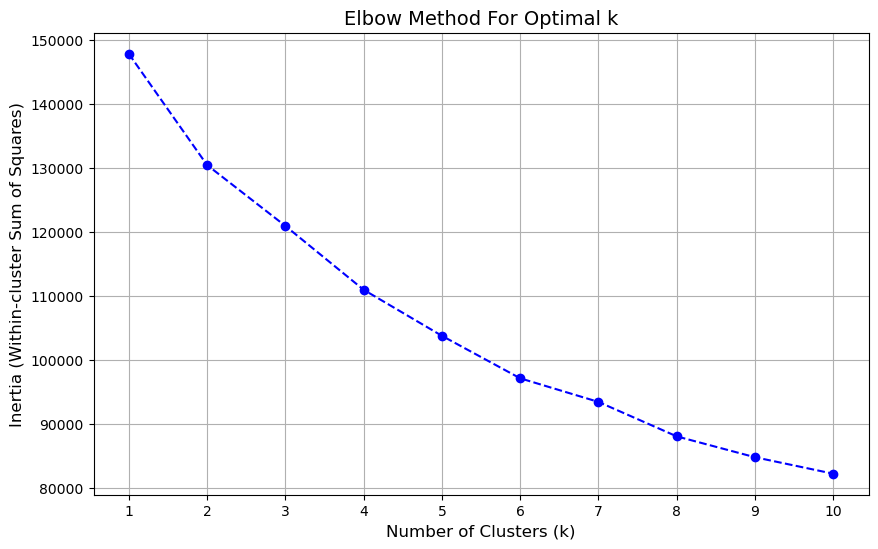

In [33]:
# 엘보우 그래프 시각화
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.title('Elbow Method For Optimal k', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Within-cluster Sum of Squares)', fontsize=12)
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [34]:
# 실루엣 계수 출력
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = {}

# k = 3 ~ 6
for k in range(3, 7):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    cluster_labels = kmeans.fit_predict(X_clust)
    
    # 실루엣 계수 계산
    score = silhouette_score(X_clust, cluster_labels)
    silhouette_scores[k] = score
    
    print(f"k = {k}, silhouette score = {score:.4f}")

k = 3, silhouette score = 0.1121
k = 4, silhouette score = 0.1172
k = 5, silhouette score = 0.1141
k = 6, silhouette score = 0.1257


In [35]:
# 클러스터링 수행
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_clust)

In [36]:
# 클러스터별 중심점(특성) 분석
cluster_analysis = df.groupby('cluster')[final_features].mean()

print(f"--- 클러스터별 변수 평균값 (k={n_clusters}) ---")
display(cluster_analysis)

--- 클러스터별 변수 평균값 (k=4) ---


,attendance,windspeed,vruns,hruns,weather_severity,dir_weight,wind_impact,run_diff,total_innings,extra_run_diff,time_per_9_innings,usedh,season_spring,season_summer,is_weekend,more_game,is_night,is_dome,is_extra
cluster,,,,,,,,,,,,,,,,,,,
0,28035.864377,8.629238,4.475782,4.636504,0.866358,-0.412814,-3.330471,3.693087,8.805042,0.049097,174.940225,0.899384,0.343901,0.477103,0.506825,0.036548,0.615368,0.001541,0.042712
1,26959.004205,8.982618,4.587048,4.586207,0.699748,1.000000,8.982618,3.661060,8.823802,0.044295,175.023832,0.897953,0.344828,0.507429,0.485842,0.025231,0.626297,0.000841,0.041211
2,26634.106752,6.558394,5.934307,4.067518,0.596715,0.131387,1.208029,1.976277,10.525547,-1.866788,176.826721,0.901460,0.313869,0.527372,0.492701,0.029197,0.636861,0.173358,1.000000
3,25314.929335,2.074525,3.989905,4.245546,0.023456,-0.016924,-0.106295,3.449822,8.825267,0.060867,172.116832,0.917755,0.323931,0.479216,0.477732,0.014846,0.638064,0.597981,0.049881


In [37]:
from sklearn.decomposition import PCA

# k=4로 클러스터링 확정
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(vif_df_updated)

In [38]:
# PCA를 이용한 시각화 (다차원 변수를 2차원으로 축소)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(vif_df_updated)
pca_df = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
pca_df['cluster'] = df['cluster']

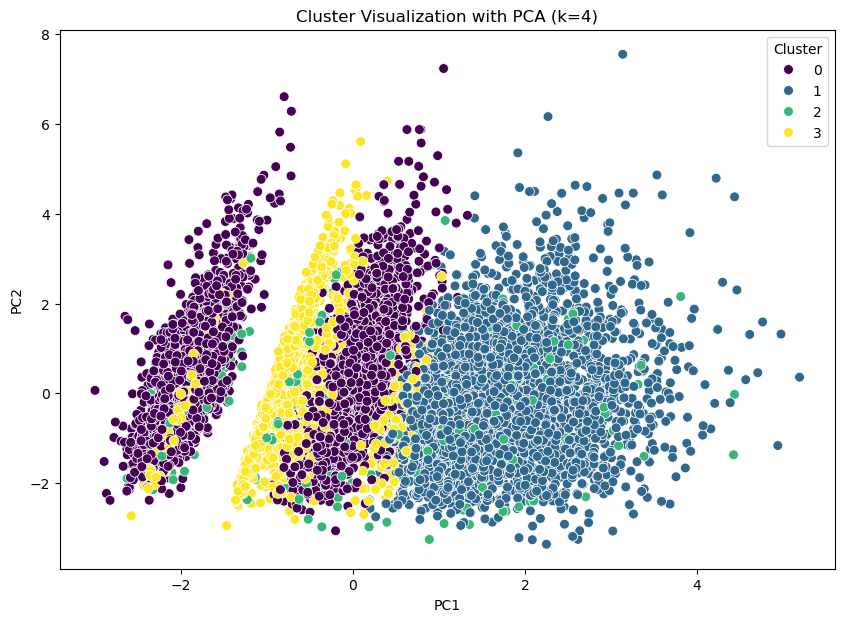

In [39]:
# 시각화
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=pca_df, palette='viridis', s=50)
plt.title(f'Cluster Visualization with PCA (k={n_clusters})')
plt.legend(title='Cluster')
plt.show()

In [40]:
# 실루엣 스코어 확인
from sklearn.metrics import silhouette_score

score = silhouette_score(vif_df_updated, df['cluster'])
print(f"실루엣 점수: {score:.4f}")

실루엣 점수: 0.1172


In [41]:
from sklearn.decomposition import PCA

# 누적 설명 분산이 80% 이상이 되는 주성분 개수 선택
pca = PCA(n_components=0.8) 
X_pca = pca.fit_transform(vif_df_updated)

# 축소된 차원으로 다시 KMeans 
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster_pca'] = kmeans_pca.fit_predict(X_pca)

# 실루엣 점수 재확인
from sklearn.metrics import silhouette_score
new_score = silhouette_score(X_pca, df['cluster_pca'])
print(f"PCA 후 실루엣 점수: {new_score:.4f}")

PCA 후 실루엣 점수: 0.1432


--- 마이애미 말린스(MIA)의 클러스터 분포 ---
Cluster 0: 85경기 (23.61%)
Cluster 1: 55경기 (15.28%)
Cluster 2: 220경기 (61.11%)


C:\Users\강태희\AppData\Local\Temp\ipykernel_4476\3101549111.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cluster_pca', data=mia_data, palette='viridis')


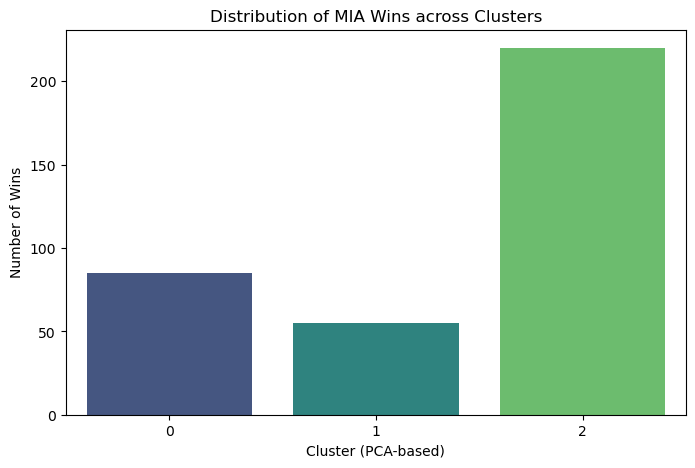

In [42]:
# 1. MIA 데이터만 필터링
mia_data = df[df['wteam'] == 'MIA']

# 2. MIA의 클러스터별 빈도 및 비율 계산
mia_cluster_counts = mia_data['cluster_pca'].value_counts().sort_index()
mia_cluster_pct = mia_data['cluster_pca'].value_counts(normalize=True).sort_index() * 100

# 결과 출력
print("--- 마이애미 말린스(MIA)의 클러스터 분포 ---")
for cluster_num, count in mia_cluster_counts.items():
    print(f"Cluster {cluster_num}: {count}경기 ({mia_cluster_pct[cluster_num]:.2f}%)")

# 3. 시각화 (막대 그래프)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(x='cluster_pca', data=mia_data, palette='viridis')
plt.title('Distribution of MIA Wins across Clusters')
plt.xlabel('Cluster (PCA-based)')
plt.ylabel('Number of Wins')
plt.show()

In [43]:
# 전체 팀의 클러스터 분포 비율
total_cluster_pct = df['cluster_pca'].value_counts(normalize=True).sort_index() * 100

# 데이터프레임으로 합쳐서 비교
comparison_df = pd.DataFrame({
    'Total_Average (%)': total_cluster_pct,
    'MIA_Only (%)': mia_cluster_pct
}).fillna(0)

print("\n--- 전체 평균 vs MIA 클러스터 비중 비교 ---")
print(comparison_df)

# 차이(Difference) 계산 - MIA가 어떤 성격의 경기를 더 많이 이겼는지 확인
comparison_df['Diff'] = comparison_df['MIA_Only (%)'] - comparison_df['Total_Average (%)']
print("\nMIA가 상대적으로 더 많이 분포한 클러스터 (Diff가 양수인 곳):")
print(comparison_df.sort_values(by='Diff', ascending=False))


--- 전체 평균 vs MIA 클러스터 비중 비교 ---
             Total_Average (%)  MIA_Only (%)
cluster_pca                                 
0                    37.904366     23.611111
1                    30.769231     15.277778
2                    31.326403     61.111111

MIA가 상대적으로 더 많이 분포한 클러스터 (Diff가 양수인 곳):
             Total_Average (%)  MIA_Only (%)       Diff
cluster_pca                                            
2                    31.326403     61.111111  29.784708
0                    37.904366     23.611111 -14.293255
1                    30.769231     15.277778 -15.491453


In [44]:
cluster_analysis_pca = df.groupby('cluster_pca')[final_features].mean()

print(f"--- 클러스터별 변수 평균값 (k={n_clusters}) ---")
display(cluster_analysis_pca)

--- 클러스터별 변수 평균값 (k=4) ---


,attendance,windspeed,vruns,hruns,weather_severity,dir_weight,wind_impact,run_diff,total_innings,extra_run_diff,time_per_9_innings,usedh,season_spring,season_summer,is_weekend,more_game,is_night,is_dome,is_extra
cluster_pca,,,,,,,,,,,,,,,,,,,
0,27837.553971,8.634050,4.519307,4.591268,0.908951,-0.421457,-3.421896,3.629223,8.874287,-0.037078,175.036996,0.898420,0.351470,0.473014,0.509434,0.037736,0.613646,0.001316,0.082931
1,26930.397297,9.000541,4.664865,4.562973,0.704054,1.000000,9.000541,3.596486,8.899459,-0.042162,174.998969,0.898919,0.345946,0.508919,0.485946,0.025405,0.625135,0.001081,0.083784
2,25705.281524,2.431643,4.120520,4.283515,0.023626,-0.019113,-0.129281,3.367667,8.914654,-0.029732,172.594700,0.916379,0.311388,0.488718,0.476241,0.014866,0.641625,0.559862,0.097956


1. Cluster 2는 '마이애미 말린스의 승리 공식'입니다
압도적인 비중: 전체 평균적으로 Cluster 2에 해당하는 경기는 31.3%에 불과하지만, MIA의 승리 경기 중 무려 61.1%가 이 군집에 몰려 있음   
상대적 특이성 (Diff: +29.78): 일반적인 팀들보다 MIA는 Cluster 2 환경에서 이길 확률이 약 2배 가깝게 높다는 것을 의미함.  


2. Cluster 0과 1은 MIA가 피해야 할 환경
비중 급감 (Diff: -14.29, -15.49): 전체 평균에 비해 MIA는 Cluster 0과 1에서의 승리 비중이 절반 가까이 낮음. 

--- 뉴욕 양키스의 클러스터 분포 ---
Cluster 0: 213경기 (46.61%)
Cluster 1: 148경기 (32.39%)
Cluster 2: 96경기 (21.01%)


C:\Users\강태희\AppData\Local\Temp\ipykernel_4476\1381142536.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cluster_pca', data=nya_data, palette='viridis')


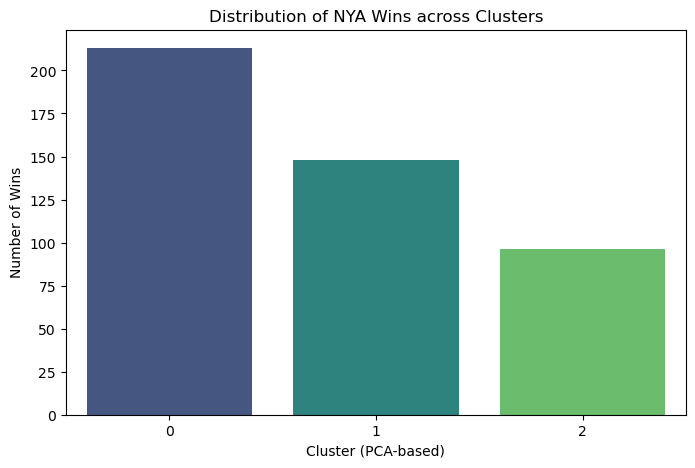

In [45]:
# 1. MIA 데이터만 필터링
nya_data = df[df['wteam'] == 'NYA']

# 2. MIA의 클러스터별 빈도 및 비율 계산
nya_cluster_counts = nya_data['cluster_pca'].value_counts().sort_index()
nya_cluster_pct = nya_data['cluster_pca'].value_counts(normalize=True).sort_index() * 100

# 결과 출력
print("--- 뉴욕 양키스의 클러스터 분포 ---")
for cluster_num, count in nya_cluster_counts.items():
    print(f"Cluster {cluster_num}: {count}경기 ({nya_cluster_pct[cluster_num]:.2f}%)")

# 3. 시각화 (막대 그래프)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(x='cluster_pca', data=nya_data, palette='viridis')
plt.title('Distribution of NYA Wins across Clusters')
plt.xlabel('Cluster (PCA-based)')
plt.ylabel('Number of Wins')
plt.show()

MIA는 Cluster 2에서 우세, NYA는 Cluster 0에서 우세  

- Cluster 0 (양키스 존): 이 군집은 득점(vruns, hruns)이 높고, 관중(attendance)이 많으며, 경기 시간이 길다. 자본력이 풍부하고 홈런 타자가 많은 양키스가 압도적인 화력으로 찍어누르는 경기들임.  
- Cluster 2 (마이애미 존): 이 군집은 상대적으로 저득점 투수전, 혹은 환경적 변수(wind_impact, weather_severity)가 크게 작용하는 경기일 가능성이 매우 높습니다. MIA는 대단한 스타 플레이어가 없어도, 짠물 투수력이나 작전 야구, 혹은 열악한 환경을 극복하는 방식으로 효율적인 승리를 챙기고 있다는 뜻입니다.

----

# **변수 중요도 추출**

In [46]:
#  PCA 로딩값 확인 코드
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(vif_df_updated)

# 각 주성분에 대한 변수들의 기여도(절대값) 확인
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'], 
    index=vif_df_updated.columns
)

# PC1(데이터 변동을 가장 많이 설명하는 축) 기준 중요도 정렬
print(loadings['PC1'].abs().sort_values(ascending=False))

wind_impact           0.662499
dir_weight            0.645865
windspeed             0.299896
weather_severity      0.108396
time_per_9_innings    0.107991
vruns                 0.100070
hruns                 0.081069
run_diff              0.079158
is_dome               0.075980
attendance            0.033217
extra_run_diff        0.021387
season_spring         0.013798
usedh                 0.010616
is_weekend            0.007504
is_night              0.004354
total_innings         0.003991
is_extra              0.003517
season_summer         0.003269
more_game             0.000189
Name: PC1, dtype: float64


중요도가 0.1 이상인 변수만 가지고 클러스터링 진행 

In [47]:
important_features= ['wind_impact', 'windspeed','weather_severity', 'time_per_9_innings','run_diff','is_dome']

In [48]:
df_import= vif_df_updated[important_features]
df_import.head()

,wind_impact,windspeed,weather_severity,time_per_9_innings,run_diff,is_dome
0,0.711084,-0.166029,0.705285,0.286954,-0.917490,0
1,-0.222884,0.040519,-0.929459,2.774724,-0.555877,0
2,2.267698,1.899452,0.705285,1.550701,0.528962,0
3,0.555423,-0.372577,-0.929459,2.744930,-0.194264,0
4,2.112036,1.692904,2.340030,0.823239,-0.917490,0


In [49]:
# 실루엣 계수 출력
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = {}

# k = 3 ~ 6
for k in range(3, 7):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    cluster_labels = kmeans.fit_predict(df_import)
    
    # 실루엣 계수 계산
    score = silhouette_score(df_import, cluster_labels)
    silhouette_scores[k] = score
    
    print(f"k = {k}, silhouette score = {score:.4f}")

k = 3, silhouette score = 0.2148
k = 4, silhouette score = 0.2216
k = 5, silhouette score = 0.2163
k = 6, silhouette score = 0.2208


In [50]:
from sklearn.decomposition import PCA

# k=4로 클러스터링 확정
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df['cluster_import'] = kmeans.fit_predict(df_import)

In [51]:
# PCA를 이용한 시각화 (다차원 변수를 2차원으로 축소)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_import)
pca_df = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
pca_df['cluster'] = df['cluster_import']

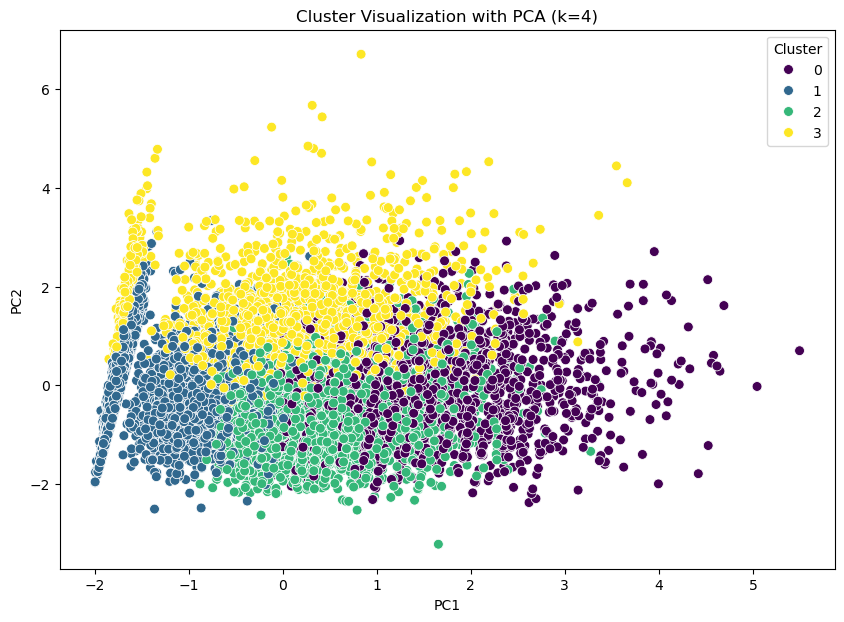

In [52]:
# 시각화
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=pca_df, palette='viridis', s=50)
plt.title(f'Cluster Visualization with PCA (k={n_clusters})')
plt.legend(title='Cluster')
plt.show()

In [53]:
cluster_analysis_import = df.groupby('cluster_import')[important_features].mean()

print(f"--- 클러스터별 변수 평균값 (k={n_clusters}) ---")
display(cluster_analysis_import)

--- 클러스터별 변수 평균값 (k=4) ---


,wind_impact,windspeed,weather_severity,time_per_9_innings,run_diff,is_dome
cluster_import,,,,,,
0,10.200170,11.939097,0.592845,176.497019,2.876491,0.001278
1,-0.360301,3.449708,0.000000,172.312943,2.722546,0.465258
2,-1.625700,7.257506,1.153181,172.669121,2.617048,0.000000
3,0.698958,6.782342,0.559779,179.788059,8.761496,0.123237


In [54]:
df.groupby('cluster_import').size()

cluster_import
0    2348
1    4116
2    3930
3    1631
dtype: int64

--- 마이애미 말린스(MIA)의 클러스터 분포 ---
Cluster 0: 37경기 (10.28%)
Cluster 1: 220경기 (61.11%)
Cluster 2: 73경기 (20.28%)
Cluster 3: 30경기 (8.33%)


C:\Users\강태희\AppData\Local\Temp\ipykernel_4476\2054854585.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cluster_import', data=mia_data, palette='viridis')


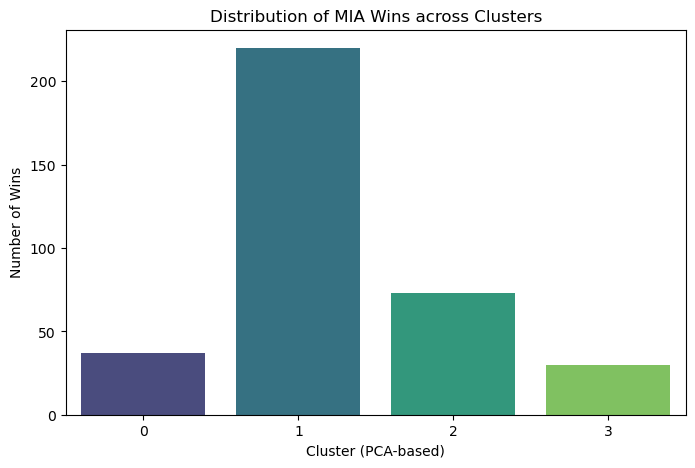

In [55]:
# 1. MIA 데이터만 필터링
mia_data = df[df['wteam'] == 'MIA']

# 2. MIA의 클러스터별 빈도 및 비율 계산
mia_cluster_counts = mia_data['cluster_import'].value_counts().sort_index()
mia_cluster_pct = mia_data['cluster_import'].value_counts(normalize=True).sort_index() * 100

# 결과 출력
print("--- 마이애미 말린스(MIA)의 클러스터 분포 ---")
for cluster_num, count in mia_cluster_counts.items():
    print(f"Cluster {cluster_num}: {count}경기 ({mia_cluster_pct[cluster_num]:.2f}%)")

# 3. 시각화 (막대 그래프)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(x='cluster_import', data=mia_data, palette='viridis')
plt.title('Distribution of MIA Wins across Clusters')
plt.xlabel('Cluster (PCA-based)')
plt.ylabel('Number of Wins')
plt.show()

### 마이애미 말린스 클러스터 분석 
- 마이애미는 'Cluster 1(61.11%)'에서 압도적 비중을 가짐.  
- 마이애미 말린스의 홈구장인 론디포 파크(LoanDepot Park)는 개폐식 돔구장 **→**  플로리다의 고온다습한 기후와 잦은 소나기(스콜)를 피하기 위해 경기의 대부분을 돔을 닫은 채 진행
- 날씨 악화 정도(`weather_severity`)가 0이고 바람이 불지 않는 환경(Cluster 1)이 이토록 많이 잡힌 것은 구장 환경이 데이터에 그대로 투영되었음을 증명

--- 뉴욕 양키스의 클러스터 분포 ---
Cluster 0: 109경기 (23.85%)
Cluster 1: 113경기 (24.73%)
Cluster 2: 157경기 (34.35%)
Cluster 3: 78경기 (17.07%)


C:\Users\강태희\AppData\Local\Temp\ipykernel_4476\3753566518.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cluster_import', data=nya_data, palette='viridis')


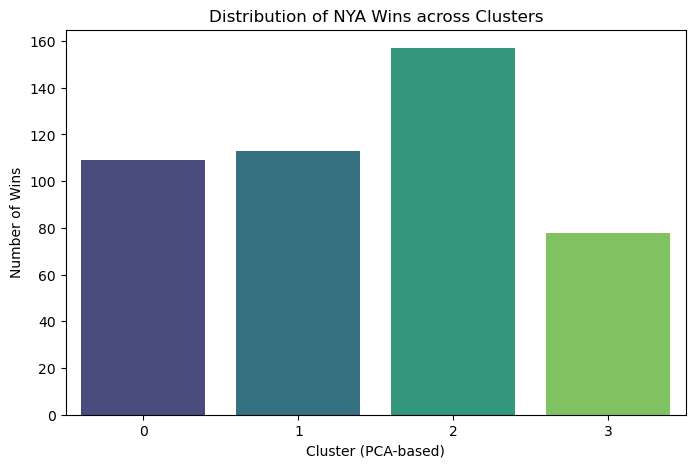

In [56]:
# 1. NYA 데이터만 필터링
nya_data = df[df['wteam'] == 'NYA']

# 2. NYA의 클러스터별 빈도 및 비율 계산
nya_cluster_counts = nya_data['cluster_import'].value_counts().sort_index()
nya_cluster_pct = nya_data['cluster_import'].value_counts(normalize=True).sort_index() * 100

# 결과 출력
print("--- 뉴욕 양키스의 클러스터 분포 ---")
for cluster_num, count in nya_cluster_counts.items():
    print(f"Cluster {cluster_num}: {count}경기 ({nya_cluster_pct[cluster_num]:.2f}%)")

# 3. 시각화 (막대 그래프)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(x='cluster_import', data=nya_data, palette='viridis')
plt.title('Distribution of NYA Wins across Clusters')
plt.xlabel('Cluster (PCA-based)')
plt.ylabel('Number of Wins')
plt.show()

### **뉴욕 양키스 클러스터 분석**
- **Cluster 0 & 2 높은 비중: 뉴욕의 거친 야외 환경**  
뉴욕 양키스의 홈구장인 양키 스타디움은 전통적인 지붕 없는 야외 구장  
-> 뉴욕의 봄·가을철 쌀쌀하고 변화무쌍한 날씨, 그리고 야외 구장 특유의 강한 바람(특히 양키스타디움 우측 펜스로 부는 제트기류 등)이 반영되면서 자연스럽게 날씨와 바람의 영향을 받는 군집(cluster 0, 2)에 높은 비율로 매칭된 것

- **Cluster 3의 극명한 차이로 팀 화력과 경기 성향을 파악할 수 있음**  
경기가 일방적이거나 스코어가 크게 벌어지는 Cluster 3에서 두 팀은 2배 가까운 차이(MIA 8.33% vs NYY 17.07%)를 보임  
뉴욕 양키스는 '브롱스 폭격기(Bronx Bombers)'라는 별명답게 강력한 홈런포를 앞세운 대형 타선이 강력함.  
홈구장 우측 펜스도 짧아 홈런이 많이 터지며, 이로 인해 점수 차가 크게 벌어지거나 경기 시간이 길어지는 난타전(Cluster 3) 패턴이 마이애미보다 훨씬 자주 발생함

--- 로스앤젤레스 다저스의 클러스터 분포 ---
Cluster 0: 101경기 (19.88%)
Cluster 1: 197경기 (38.78%)
Cluster 2: 113경기 (22.24%)
Cluster 3: 97경기 (19.09%)


C:\Users\강태희\AppData\Local\Temp\ipykernel_4476\4109230110.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cluster_import', data=lan_data, palette='viridis')


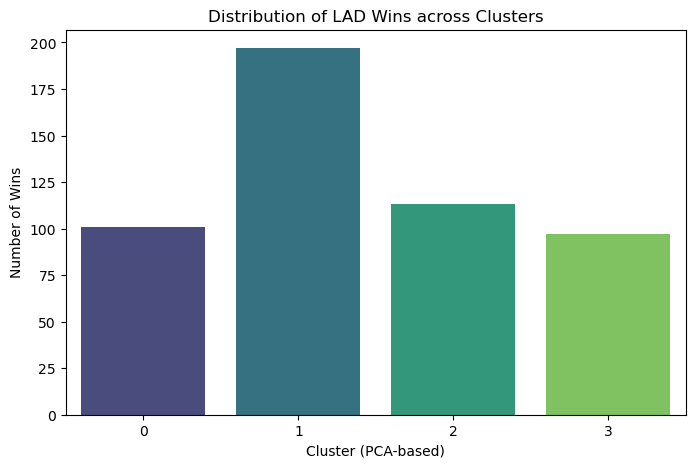

In [58]:
# 1. LAN 데이터만 필터링
lan_data = df[df['wteam'] == 'LAN']

# 2. LAN의 클러스터별 빈도 및 비율 계산
lan_cluster_counts = lan_data['cluster_import'].value_counts().sort_index()
lan_cluster_pct = lan_data['cluster_import'].value_counts(normalize=True).sort_index() * 100

# 결과 출력
print("--- 로스앤젤레스 다저스의 클러스터 분포 ---")
for cluster_num, count in lan_cluster_counts.items():
    print(f"Cluster {cluster_num}: {count}경기 ({lan_cluster_pct[cluster_num]:.2f}%)")

# 3. 시각화 (막대 그래프)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(x='cluster_import', data=lan_data, palette='viridis')
plt.title('Distribution of LAD Wins across Clusters')
plt.xlabel('Cluster (PCA-based)')
plt.ylabel('Number of Wins')
plt.show()

### **LA 다저스 클러스터 분석**
1. **환경적 요인: 돔구장만큼 안정적인 LA의 사막성 기후**
Cluster 1의 핵심 정의는 weather_severity = 0.00 (날씨 악화 없음)과 낮은 풍속임   
마이애미는 돔을 닫아서 이 환경을 인위적으로 만들었다면, LA는 자연환경 자체가 이미 돔구장 수준으로 완벽함  
비가 오지 않는 기후: LA는 지중해성/사막성 기후에 속해, 프로야구 시즌인 4월부터 10월까지 비가 거의 내리지 않음. 따라서 기상 악화 지표인 weather_severity가 0에 수렴  
잔잔한 바람: 다저 스타디움은 지형적으로 '차베스 래빈(Chavez Ravine)'이라는 분지/계곡 형태의 언덕을 깎아 만듦. 구장 주변이 언덕으로 둘러싸여 있어, 샌프란시스코나 시카고 같은 다른 해안·호수 인접 구장에 비해 바람의 영향이 매서운 편이 아님  

2. **경기력적 요인: 강팀의 '무난하고 깔끔한 승리' 패턴**   
Cluster 1의 경기력적 특성: 경기 시간(time_per_9_innings)이 짧고 득점 차(run_diff)가 2점대로 타이트하면서도 깔끔하게 끝나는 '표준적이고 안정적인 경기'
기후 변수도 없고 경기 시간도 질질 끌지 않으면서, 2~3점 차이로 상대 타선을 꽁꽁 묶어 정석적으로 승리를 가져간 경기가 많았기 때문에 승리 경기 중에서 Cluster 1이 압도적인 1위를 차지하게 된 것  

--- 오클랜드 애슬레틱스의 클러스터 분포 ---
Cluster 0: 126경기 (47.91%)
Cluster 1: 78경기 (29.66%)
Cluster 2: 38경기 (14.45%)
Cluster 3: 21경기 (7.98%)


C:\Users\강태희\AppData\Local\Temp\ipykernel_4476\257761007.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cluster_import', data=oak_data, palette='viridis')


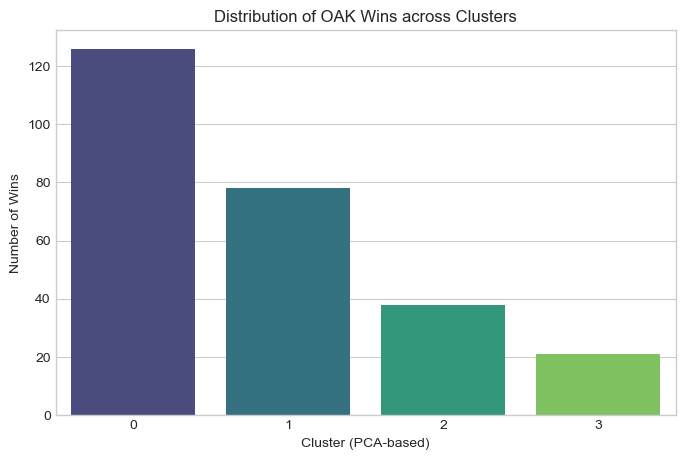

In [63]:
# 1. OAK 데이터만 필터링
oak_data = df[df['wteam'] == 'OAK']

# 2. OAK의 클러스터별 빈도 및 비율 계산
oak_cluster_counts = oak_data['cluster_import'].value_counts().sort_index()
oak_cluster_pct = oak_data['cluster_import'].value_counts(normalize=True).sort_index() * 100

# 결과 출력
print("--- 오클랜드 애슬레틱스의 클러스터 분포 ---")
for cluster_num, count in oak_cluster_counts.items():
    print(f"Cluster {cluster_num}: {count}경기 ({oak_cluster_pct[cluster_num]:.2f}%)")

# 3. 시각화 (막대 그래프)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(x='cluster_import', data=oak_data, palette='viridis')
plt.title('Distribution of OAK Wins across Clusters')
plt.xlabel('Cluster (PCA-based)')
plt.ylabel('Number of Wins')
plt.show()

In [59]:
# 시즌별 마이애미 말린스 팀의 클러스터 분포 확인
season_cluster_counts = pd.crosstab(
    mia_data["season"], mia_data["cluster_import"]
)
season_cluster_pct = pd.crosstab(
    mia_data["season"], mia_data["cluster_import"], normalize="index"
) * 100

print("--- [마이애미 말린스] 시즌별 클러스터 경기 수 ---")
print(season_cluster_counts)
print("\n--- [마이애미 말린스] 시즌별 클러스터 비율 (%) ---")
print(season_cluster_pct.round(2))

--- [마이애미 말린스] 시즌별 클러스터 경기 수 ---
cluster_import   0   1   2  3
season                       
2021             2  45  11  8
2022            11  43  10  5
2023             6  52  19  7
2024             7  37  12  6
2025            11  43  21  4

--- [마이애미 말린스] 시즌별 클러스터 비율 (%) ---
cluster_import      0      1      2      3
season                                    
2021             3.03  68.18  16.67  12.12
2022            15.94  62.32  14.49   7.25
2023             7.14  61.90  22.62   8.33
2024            11.29  59.68  19.35   9.68
2025            13.92  54.43  26.58   5.06


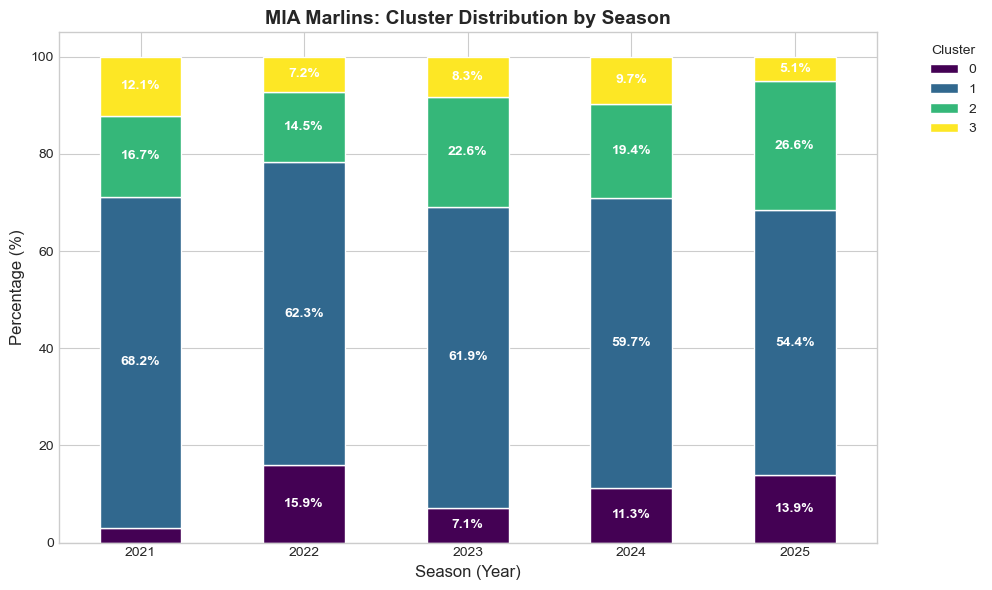

In [60]:
# 시각화 
plt.style.use("seaborn-v0_8-whitegrid") 

# 100% 누적 바 차트 그리기
ax = season_cluster_pct.plot(
    kind="bar", stacked=True, figsize=(10, 6), colormap="viridis", edgecolor="w"
)

plt.title("MIA Marlins: Cluster Distribution by Season", fontsize=14, fontweight="bold")
plt.xlabel("Season (Year)", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 5: # 비율이 너무 작으면 글자가 겹치므로 5% 이상일 때만 표시
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.1f}%', 
                horizontalalignment='center', 
                verticalalignment='center',
                color='white',
                fontsize=10,
                fontweight='bold')

plt.tight_layout()
plt.show()

#### **2023년: MIA가 포스트시즌에 진출한 시즌**  
Cluster 3(난타전) 비율이 8.33%로 낮게 유지되면서, Cluster 2(악천후/역풍 야외) 비율이 22.62%로 전년 대비 크게 증가함  
난타전(Cluster 3) 비중이 낮다 -> 팀의 장타 화력이 대단치 않았음. BUT 가성비 좋게 승리를 가져갔던 시즌임. 특히 악천후나 역풍 환경인 Cluster 2의 비중이 높았음에도 좋은 성적을 냈다는 것은, 2023년의 마이애미가 원정 야외 구장의 불리함과 거친 날씨를 극복하여 한 점 차 승부에 매우 강했다는 것을 나타냄 (2023년 1점 차 경기에서 33승 14패 승률 기록)

#### **2025년: '탈-돔구장화'와 경기력 침체 패턴**
5개년 중 Cluster 1(54.43%)이 가장 낮고, 반대로 외풍과 악천후의 영향(Cluster 0, 2)이 도합 40.5%로 최고치를 찍었음. 반면 Cluster 3(난타전)은 5.06%로 **역대 최저**
Cluster 3가 5.06%로 최하 -> 팀의 화력이 완전히 바닥을 쳐서 대량 득점으로 시원하게 이기는 경기 자체가 실종되었고, 거친 야외 환경에 노출되는 빈도가 늘어나면서 팀 전체가 고전했을 확률이 매우 높음  

--- 전체 클러스터별 총합 대비 MIA 경기 비율 (%) ---
cluster_import     0     1     2     3
wteam                                 
MIA             1.58  5.34  1.86  1.84


C:\Users\강태희\AppData\Local\Temp\ipykernel_4476\688545844.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=mia_series.index, y=mia_series.values, palette="viridis")


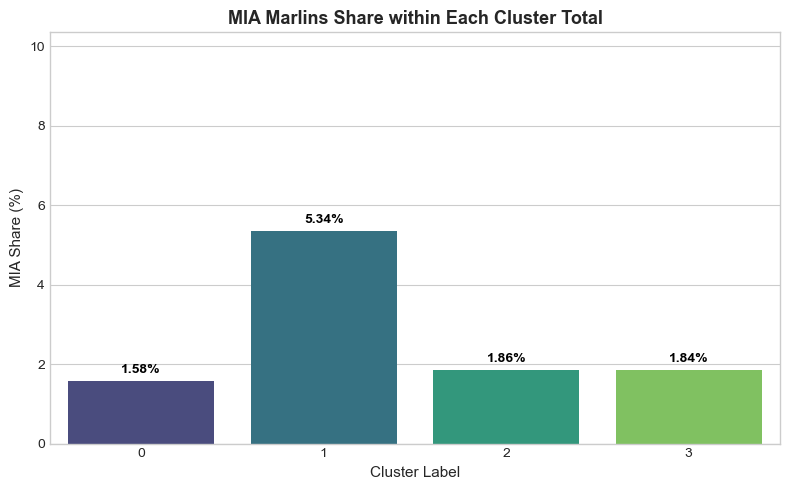

In [62]:
# 각 클러스터 내에서 마이애미가 차지하는 비중
cluster_team_pct = pd.crosstab(
    df["wteam"], df["cluster_import"], normalize="columns"
) * 100

mia_share_pct = cluster_team_pct.loc[["MIA"]]

print("--- 전체 클러스터별 총합 대비 MIA 경기 비율 (%) ---")
print(mia_share_pct.round(2))

# 3. 시각화 
plt.figure(figsize=(8, 5))
plt.style.use("seaborn-v0_8-whitegrid")

# 마이애미의 비율 데이터만 가볍게 시리즈로 변환
mia_series = mia_share_pct.iloc[0]
ax = sns.barplot(x=mia_series.index, y=mia_series.values, palette="viridis")

plt.title("MIA Marlins Share within Each Cluster Total", fontsize=13, fontweight="bold")
plt.xlabel("Cluster Label", fontsize=11)
plt.ylabel("MIA Share (%)", fontsize=11)
plt.ylim(0, max(mia_series.values) + 5) 

# 바 차트 위에 정확한 수치 레이블 표시
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 8), 
                textcoords='offset points',
                fontweight='bold',
                color='black')

plt.tight_layout()
plt.show()